# Evaluating the Impact of Image Augmentation Strategies on CNN Architectures in Skin Lesion Classification

**DS 6050, SP 2026 - ML III: Deep Learning Project** *For Professor Heman Shakeri, PhD, University of Virginia*

---

### Team Members
* **Robert Ashby** | *University of Virginia, School of Data Science* | Fernandina Beach, Florida | gsr3qz@virginia.edu
* **Xavier Colbert** | *University of Virginia, School of Data Science* | Alexandria, Virginia | kxp3jj@virginia.edu
* **Jacob Kuchta** | *University of Virginia, School of Data Science* | Arlington, Virginia | mjk3ku@virginia.edu
* **Alysa Pugmire** | *University of Virginia, School of Data Science* | Richmond, Virginia | amp3xs@virginia.edu

# Notebook 06, External Validation and Generalization Study

## Notebook purpose

This notebook runs the **external validation study** for the skin lesion classification project.

In `04_ablation_study.ipynb`, the project trained three CNN backbones on the ISIC 2019 training split and evaluated cumulative augmentation stages on the ISIC 2019 validation split. The purpose of this notebook is different. Here, the trained models from Notebook 04 are evaluated on an **external dataset**, MILK10K, to test whether augmentation gains persist under cross-dataset distribution shift.

A few design choices are important:

1. **MILK10K is external-only.**  
   No MILK10K images are used for model fitting, checkpoint selection, or hyperparameter tuning in this notebook.

2. **The MILK10K training partition is used as the external evaluation set.**  
   In this project, the partition named "training" is used only because it is the portion with available ground-truth lesion diagnoses.

3. **Lesion-level evaluation is the primary analysis.**  
   Each MILK10K lesion has two associated images. Predictions are generated at the image level, then aggregated to the lesion level by averaging class probabilities across the two images. Because the diagnosis is defined at the lesion level, lesion-level metrics are treated as primary, while image-level metrics are retained as supplementary diagnostics.

4. **The initial external comparison focuses on the final cumulative augmentation stage.**  
   The first pass in this notebook compares the three backbones at `phase1_plus_2_plus_3_plus_4`, then later expands to the full 12-model external ablation ladder.

5. **Label-space compatibility is handled explicitly.**  
   MILK10K contains several diagnosis categories that are not part of the 8-class ISIC 2019 training label space. For the initial image-only external evaluation, Notebook 06 restricts analysis to lesions whose MILK diagnoses map directly onto the ISIC 8-class target set.

## Execution structure

This notebook supports two execution modes.

### 1. Smoke-test mode

Smoke mode is used to verify that the external evaluation pipeline works end to end on a small lesion-stratified subset of the MILK10K external dataset.

This mode is intended to test:

- raw-file loading
- label harmonization
- image-path construction
- lesion-level aggregation
- checkpoint loading
- metric computation
- confusion-matrix generation
- output saving

### 2. Full mode

Full mode runs the complete MILK10K external validation study.

Because HPC access windows can be limited, this notebook is designed to support **one-backbone-at-a-time execution** without changing the scientific design. A typical full run can therefore be organized as:

- Session 1, ResNet-50 external evaluation
- Session 2, EfficientNet-B0 external evaluation
- Session 3, DenseNet-121 external evaluation
- Final aggregation session, combine results and generate summary plots

### Planned external-evaluation order

This notebook is intentionally staged in two steps.

**Step A, initial external comparison**
- Evaluate the three `phase1_plus_2_plus_3_plus_4` checkpoints on MILK10K
- Compare lesion-level macro AUC and balanced accuracy
- Compute the ISIC to MILK10K generalization gap for each backbone

**Step B, full external ablation**
- Evaluate all four augmentation stages for each backbone
- Replicate the cumulative ablation ladder externally
- Test whether augmentation narrows the cross-dataset generalization gap

In [1]:
# ============================================================
# NOTEBOOK 06 CONFIGURATION
# ============================================================

SMOKE_MODE = True

# Run the three final-stage models first, then expand later
INITIAL_EXTERNAL_ONLY = True
PRIMARY_STAGE = "phase1_plus_2_plus_3_plus_4"

ABLATION_STAGES = [
    "baseline",
    "phase1_plus_2",
    "phase1_plus_2_plus_3",
    "phase1_plus_2_plus_3_plus_4",
]

BACKBONES = [
    "resnet50",
    "efficientnet_b0",
    "densenet121",
]

# For short HPC sessions, this list can be reduced to one backbone
BACKBONES_TO_RUN = BACKBONES.copy()

# Smoke-mode sampling is done at the lesion level, not the image level
SMOKE_LESIONS_PER_SUPPORTED_CLASS = 40
SMOKE_RANDOM_STATE = 42

IMAGE_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 0

SAVE_PREDICTIONS = True
SAVE_FIGURES = True
SAVE_REPORTS = True
SAVE_SUMMARY_TABLES = True

EXPERIMENT_SEED = 42

## Imports and project-root setup

This section imports the core Python, PyTorch, and evaluation libraries used throughout the notebook, then resolves the project root so the notebook can consistently find the shared `scripts/` directory and prior project outputs.

Unlike Notebook 04, this notebook is **inference-first**, not training-first. As a result, the imports emphasize:

- data loading
- checkpoint loading
- metric computation
- confusion matrices
- prediction aggregation
- figure generation

Only the backbone model builders are imported from `scripts/`. The augmentation helper modules are not needed for external inference because evaluation uses the fixed validation transform rather than train-time augmentation.

In [2]:
from pathlib import Path
import sys
import json
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from IPython.display import display

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from sklearn.metrics import (
    balanced_accuracy_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
)

In [3]:
# ============================================================
# RESOLVE PROJECT ROOT AND IMPORT SHARED MODEL BUILDERS
# ============================================================

# Resolve the project root, not just the current notebook directory
cwd = Path.cwd().resolve()
ROOT = cwd.parent if cwd.name.lower() == "code" else cwd
SCRIPTS = ROOT / "scripts"

if not SCRIPTS.exists():
    raise FileNotFoundError(f"Expected scripts directory at: {SCRIPTS}")

if str(SCRIPTS) not in sys.path:
    sys.path.append(str(SCRIPTS))

# Import only the backbone builders needed for checkpoint reconstruction
from resnet50_baseline import build_resnet50
from efficientnet_b0_baseline import build_efficientnet_b0
from densenet121_baseline import build_densenet121

MODEL_BUILDERS = {
    "resnet50": build_resnet50,
    "efficientnet_b0": build_efficientnet_b0,
    "densenet121": build_densenet121,
}

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("CWD:     ", cwd)
print("ROOT:    ", ROOT)
print("SCRIPTS: ", SCRIPTS)
print("DEVICE:  ", DEVICE)

CWD:      /sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_ML_III_Deep_Learning_Project_Ashby_Colbert_Kuchta_Pugmire/Code
ROOT:     /sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_ML_III_Deep_Learning_Project_Ashby_Colbert_Kuchta_Pugmire
SCRIPTS:  /sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_ML_III_Deep_Learning_Project_Ashby_Colbert_Kuchta_Pugmire/scripts
DEVICE:   cuda


## Save experiment configuration and set seeds

This section creates the output directories for Notebook 06, saves the active notebook configuration, and fixes the random seed for reproducibility.

Because this notebook supports both smoke mode and backbone-specific HPC execution, the saved configuration records the **overall external-evaluation setup** rather than a single run result.

In [4]:
# ============================================================
# OUTPUT DIRECTORIES, CONFIG SAVE, AND REPRODUCIBILITY
# ============================================================

OUT_ROOT = ROOT / "outputs"

CONFIG_DIR = OUT_ROOT / "configs" / "06_external_evaluation"
FIG_DIR = OUT_ROOT / "figures" / "06_external_evaluation"
METRIC_DIR = OUT_ROOT / "metrics"
PRED_DIR = OUT_ROOT / "preds"
CKPT_DIR = OUT_ROOT / "checkpoints"
REPORT_DIR = OUT_ROOT / "reports" / "06_external_evaluation"

for d in [CONFIG_DIR, FIG_DIR, METRIC_DIR, PRED_DIR, CKPT_DIR, REPORT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

EXPERIMENT_CONFIG = {
    "notebook": "06_external_evaluation",
    "seed": EXPERIMENT_SEED,
    "smoke_mode": SMOKE_MODE,
    "initial_external_only": INITIAL_EXTERNAL_ONLY,
    "primary_stage": PRIMARY_STAGE,
    "ablation_stages": ABLATION_STAGES,
    "backbones": BACKBONES,
    "backbones_to_run": BACKBONES_TO_RUN,
    "smoke_lesions_per_supported_class": SMOKE_LESIONS_PER_SUPPORTED_CLASS,
    "image_size": IMAGE_SIZE,
    "batch_size": BATCH_SIZE,
    "num_workers": NUM_WORKERS,
    "save_predictions": SAVE_PREDICTIONS,
    "save_figures": SAVE_FIGURES,
    "save_reports": SAVE_REPORTS,
    "save_summary_tables": SAVE_SUMMARY_TABLES,
}

config_path = CONFIG_DIR / ("smoke_config.json" if SMOKE_MODE else "full_config.json")

with open(config_path, "w") as f:
    json.dump(EXPERIMENT_CONFIG, f, indent=2)

def seed_everything(seed: int):
    # Fix Python, NumPy, and PyTorch randomness
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_everything(EXPERIMENT_SEED)

loader_generator = torch.Generator()
loader_generator.manual_seed(EXPERIMENT_SEED)

print("Saved config to:", config_path)
print("Global seed set.")
print("DataLoader generator seeded.")

Saved config to: /sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_ML_III_Deep_Learning_Project_Ashby_Colbert_Kuchta_Pugmire/outputs/configs/06_external_evaluation/smoke_config.json
Global seed set.
DataLoader generator seeded.


## Locate and load raw MILK10K source tables

This notebook loads the raw MILK10K **training** tables directly.

The required external-evaluation inputs are:

- `MILK10k_Training_GroundTruth.csv`
- `MILK10k_Training_Metadata.csv`
- `MILK10k_Training_Supplement.csv`
- the corresponding image directory containing lesion folders and image files

The image directory is expected to be organized as:

- one folder per `lesion_id`
- two image files per lesion folder
- image files named from `isic_id`

This section resolves those raw-file locations and loads the source tables into memory.

In [6]:
# ============================================================
# FIND MILK10K FILES USING THE PROJECT'S ACTUAL DIRECTORY LAYOUT
# ============================================================

def first_existing_path(path_candidates):
    # Return the first path that exists, or None if none exist
    for p in path_candidates:
        if p.exists():
            return p
    return None

# Base MILK directories used elsewhere in the project
MILK_BASE_CANDIDATES = [
    ROOT / "DATA" / "milk10k",
    ROOT / "DATA" / "raw" / "milk10k",
]

MILK_BASE = first_existing_path(MILK_BASE_CANDIDATES)

if MILK_BASE is None:
    raise FileNotFoundError(
        "Could not locate the MILK10K base directory.\n"
        "Checked:\n"
        + "\n".join(str(p) for p in MILK_BASE_CANDIDATES)
    )

# Training CSV files live under DATA/milk10k/train
MILK_TRAIN_DIR_CANDIDATES = [
    ROOT / "DATA" / "milk10k" / "train",
    MILK_BASE / "train",
]

MILK_TRAIN_DIR = first_existing_path(MILK_TRAIN_DIR_CANDIDATES)

if MILK_TRAIN_DIR is None:
    raise FileNotFoundError(
        "Could not locate the MILK10K training directory.\n"
        "Checked:\n"
        + "\n".join(str(p) for p in MILK_TRAIN_DIR_CANDIDATES)
    )

GT_PATH = MILK_TRAIN_DIR / "MILK10k_Training_GroundTruth.csv"
META_PATH = MILK_TRAIN_DIR / "MILK10k_Training_Metadata.csv"
SUPP_PATH = MILK_TRAIN_DIR / "MILK10k_Training_Supplement.csv"

required_paths = [GT_PATH, META_PATH, SUPP_PATH]
missing_paths = [str(p) for p in required_paths if not p.exists()]
if missing_paths:
    raise FileNotFoundError(
        "Missing required MILK10K source files:\n" + "\n".join(missing_paths)
    )

# Images may appear with one extra nested folder depending on zip extraction
TRAIN_IMAGE_ROOT_CANDIDATES = [
    MILK_TRAIN_DIR / "images" / "MILK10k_Training_Input",
    MILK_TRAIN_DIR / "images" / "MILK10k_Training_Input" / "MILK10k_Training_Input",
    MILK_TRAIN_DIR / "images",
]

TRAIN_IMAGE_ROOT = first_existing_path(TRAIN_IMAGE_ROOT_CANDIDATES)

if TRAIN_IMAGE_ROOT is None:
    raise FileNotFoundError(
        "Could not locate the MILK10K training image directory.\n"
        "Checked:\n"
        + "\n".join(str(p) for p in TRAIN_IMAGE_ROOT_CANDIDATES)
    )

milk_gt_df = pd.read_csv(GT_PATH)
milk_meta_df = pd.read_csv(META_PATH)
milk_supp_df = pd.read_csv(SUPP_PATH)

print("MILK_BASE:", MILK_BASE)
print("MILK_TRAIN_DIR:", MILK_TRAIN_DIR)
print("GT_PATH:", GT_PATH)
print("META_PATH:", META_PATH)
print("SUPP_PATH:", SUPP_PATH)
print("TRAIN_IMAGE_ROOT:", TRAIN_IMAGE_ROOT)
print()

print("milk_gt_df shape:", milk_gt_df.shape)
print("milk_meta_df shape:", milk_meta_df.shape)
print("milk_supp_df shape:", milk_supp_df.shape)

MILK_BASE: /sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_ML_III_Deep_Learning_Project_Ashby_Colbert_Kuchta_Pugmire/DATA/milk10k
MILK_TRAIN_DIR: /sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_ML_III_Deep_Learning_Project_Ashby_Colbert_Kuchta_Pugmire/DATA/milk10k/train
GT_PATH: /sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_ML_III_Deep_Learning_Project_Ashby_Colbert_Kuchta_Pugmire/DATA/milk10k/train/MILK10k_Training_GroundTruth.csv
META_PATH: /sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_ML_III_Deep_Learning_Project_Ashby_Colbert_Kuchta_Pugmire/DATA/milk10k/train/MILK10k_Training_Metadata.csv
SUPP_PATH: /sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_ML_III_Deep_Learning_Project_Ashby_Colbert_Kuchta_Pugmire/DATA/milk10k/train/MILK10k_Training_Supplement.csv
TRAIN_IMAGE_ROOT: /sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_ML_III_Deep_Learning_Project_Ashby_Colbert_Kuchta_Pugmire/DATA/milk10k/train/images/MILK10k_Training_Input

milk_gt_df shape: (5240, 12)
milk_meta_df shape: (10480, 17)
milk_

In [8]:
# Quick audit of the image root
print("Sample lesion folders:")
for p in sorted(TRAIN_IMAGE_ROOT.iterdir())[:5]:
    print(" -", p.name)

first_lesion = next((p for p in sorted(TRAIN_IMAGE_ROOT.iterdir()) if p.is_dir()), None)
if first_lesion is not None:
    print("\nFirst lesion folder:", first_lesion.name)
    print("Contained files:")
    for f in sorted(first_lesion.iterdir()):
        print("   ", f.name)

Sample lesion folders:
 - IL_0000652
 - IL_0003176
 - IL_0004688
 - IL_0005081
 - IL_0006177

First lesion folder: IL_0000652
Contained files:
    ISIC_4671410.jpg
    ISIC_8149219.jpg


## Harmonize MILK10K labels and construct external evaluation tables

MILK10K and ISIC 2019 do not use exactly the same diagnosis labels.

The image-only models trained in Notebook 04 were fit on the following 8-class ISIC label space:

- AK
- BCC
- BKL
- DF
- MEL
- NV
- SCC
- VASC

MILK10K includes several additional categories that are not part of that output space. For the initial image-only external evaluation, Notebook 06 therefore performs explicit label harmonization:

### Supported MILK to ISIC mappings
- `AKIEC` → `AK`
- `BCC` → `BCC`
- `BKL` → `BKL`
- `DF` → `DF`
- `MEL` → `MEL`
- `NV` → `NV`
- `SCCKA` → `SCC`
- `VASC` → `VASC`

### Initial unsupported categories
- `BEN_OTH`
- `INF`
- `MAL_OTH`

These unsupported lesions are excluded from the initial image-only external comparison because the trained CNN checkpoints do not have output nodes for those diagnoses.

This section builds two linked dataframes:

1. **Lesion-level table**  
   One row per lesion, with the harmonized diagnosis label

2. **Image-level table**  
   Two rows per lesion, one for each image, with the corresponding image path and harmonized lesion label

In [9]:
# ============================================================
# LABEL HARMONIZATION AND IMAGE-PATH CONSTRUCTION
# ============================================================

# Notebook 04 used the sorted ISIC labels below
CANONICAL_LABELS = ["AK", "BCC", "BKL", "DF", "MEL", "NV", "SCC", "VASC"]
CANONICAL_LABEL_TO_IDX = {label: idx for idx, label in enumerate(CANONICAL_LABELS)}
IDX_TO_CANONICAL_LABEL = {idx: label for label, idx in CANONICAL_LABEL_TO_IDX.items()}

# MILK ground-truth columns
MILK_DIAG_COLS = [
    "AKIEC",
    "BCC",
    "BEN_OTH",
    "BKL",
    "DF",
    "INF",
    "MAL_OTH",
    "MEL",
    "NV",
    "SCCKA",
    "VASC",
]

MILK_TO_ISIC_LABEL = {
    "AKIEC": "AK",
    "BCC": "BCC",
    "BKL": "BKL",
    "DF": "DF",
    "MEL": "MEL",
    "NV": "NV",
    "SCCKA": "SCC",
    "VASC": "VASC",
}

# Basic guardrail, each lesion should have exactly one positive diagnosis row
milk_gt_df = milk_gt_df.copy()
milk_gt_df["diagnosis_row_sum"] = milk_gt_df[MILK_DIAG_COLS].sum(axis=1)

if not np.allclose(milk_gt_df["diagnosis_row_sum"].values, 1.0):
    raise ValueError(
        "MILK ground-truth rows are not one-hot encoded as expected."
    )

# Extract the raw MILK diagnosis label and map into the ISIC 8-class space
milk_gt_df["milk_label_raw"] = milk_gt_df[MILK_DIAG_COLS].idxmax(axis=1)
milk_gt_df["label"] = milk_gt_df["milk_label_raw"].map(MILK_TO_ISIC_LABEL)
milk_gt_df["is_supported_label"] = milk_gt_df["label"].isin(CANONICAL_LABELS)

# Split lesion-level tables into supported and excluded subsets
milk_supported_lesions_df = milk_gt_df[milk_gt_df["is_supported_label"]].copy()
milk_excluded_lesions_df = milk_gt_df[~milk_gt_df["is_supported_label"]].copy()

milk_supported_lesions_df["label_idx"] = (
    milk_supported_lesions_df["label"].map(CANONICAL_LABEL_TO_IDX)
)

# Merge lesion labels onto the image metadata
milk_images_df = milk_meta_df.merge(
    milk_gt_df[["lesion_id", "milk_label_raw", "label", "is_supported_label"]],
    on="lesion_id",
    how="left",
    validate="many_to_one",
)

# Build image filenames and absolute image paths
milk_images_df["isic_id"] = milk_images_df["isic_id"].astype(str).str.strip()
milk_images_df["image_filename"] = milk_images_df["isic_id"] + ".jpg"
milk_images_df["image_path"] = milk_images_df.apply(
    lambda row: str(TRAIN_IMAGE_ROOT / row["lesion_id"] / row["image_filename"]),
    axis=1,
)

# Quick image-existence check
milk_images_df["image_exists"] = milk_images_df["image_path"].map(
    lambda p: Path(p).exists()
)

# Restrict to lesions supported by the current 8-class image-only models
milk_supported_images_df = milk_images_df[milk_images_df["is_supported_label"]].copy()
milk_supported_images_df["label_idx"] = (
    milk_supported_images_df["label"].map(CANONICAL_LABEL_TO_IDX)
)

# Sort for reproducible downstream evaluation
milk_supported_lesions_df = (
    milk_supported_lesions_df
    .sort_values(["label", "lesion_id"])
    .reset_index(drop=True)
)

milk_supported_images_df = (
    milk_supported_images_df
    .sort_values(["lesion_id", "image_type", "isic_id"])
    .reset_index(drop=True)
)

print("Canonical labels:", CANONICAL_LABELS)
print("Supported lesions:", len(milk_supported_lesions_df))
print("Excluded lesions:", len(milk_excluded_lesions_df))
print("Supported images:", len(milk_supported_images_df))
print()

print("Excluded MILK labels:")
print(milk_excluded_lesions_df["milk_label_raw"].value_counts().sort_index())
print()

print("Supported mapped labels:")
print(milk_supported_lesions_df["label"].value_counts().sort_index())
print()

print("Image-path existence check:")
print(milk_supported_images_df["image_exists"].value_counts(dropna=False))

Canonical labels: ['AK', 'BCC', 'BKL', 'DF', 'MEL', 'NV', 'SCC', 'VASC']
Supported lesions: 5137
Excluded lesions: 103
Supported images: 10274

Excluded MILK labels:
milk_label_raw
BEN_OTH    44
INF        50
MAL_OTH     9
Name: count, dtype: int64

Supported mapped labels:
label
AK       303
BCC     2522
BKL      544
DF        52
MEL      450
NV       746
SCC      473
VASC      47
Name: count, dtype: int64

Image-path existence check:
image_exists
True    10274
Name: count, dtype: int64


## Smoke-mode lesion sampling and final external evaluation table

If `SMOKE_MODE = True`, the notebook should reduce the external evaluation set at the **lesion level**, then keep both images for every sampled lesion.

This is important. The external evaluation target is lesion diagnosis, so the smoke subset must preserve the two-image structure for each selected lesion rather than sampling individual images independently.

The output of this section is the dataframe that the rest of Notebook 06 will use:

- `milk_eval_lesions_df`, one row per lesion in the active run
- `milk_eval_df`, two rows per lesion in the active run, one per image

In [10]:
# ============================================================
# BUILD THE ACTIVE EXTERNAL EVALUATION SUBSET
# ============================================================

def stratified_lesion_smoke_subset(lesion_df, lesions_per_class=40, random_state=42):
    # Sample lesions within each supported class
    sampled_parts = []

    for label, group in lesion_df.groupby("label", sort=True):
        n_take = min(len(group), lesions_per_class)
        sampled_group = group.sample(n=n_take, random_state=random_state)
        sampled_parts.append(sampled_group)

    out_df = pd.concat(sampled_parts, axis=0)
    out_df = out_df.sort_values(["label", "lesion_id"]).reset_index(drop=True)
    return out_df

if SMOKE_MODE:
    milk_eval_lesions_df = stratified_lesion_smoke_subset(
        milk_supported_lesions_df,
        lesions_per_class=SMOKE_LESIONS_PER_SUPPORTED_CLASS,
        random_state=SMOKE_RANDOM_STATE,
    )
else:
    milk_eval_lesions_df = milk_supported_lesions_df.copy()

milk_eval_df = milk_supported_images_df[
    milk_supported_images_df["lesion_id"].isin(milk_eval_lesions_df["lesion_id"])
].copy()

milk_eval_df = milk_eval_df.sort_values(
    ["lesion_id", "image_type", "isic_id"]
).reset_index(drop=True)

print("SMOKE_MODE:", SMOKE_MODE)
print("Evaluation lesions:", len(milk_eval_lesions_df))
print("Evaluation images:", len(milk_eval_df))
print()

print("Evaluation lesion class counts:")
print(milk_eval_lesions_df["label"].value_counts().sort_index())

SMOKE_MODE: True
Evaluation lesions: 320
Evaluation images: 640

Evaluation lesion class counts:
label
AK      40
BCC     40
BKL     40
DF      40
MEL     40
NV      40
SCC     40
VASC    40
Name: count, dtype: int64


## External-data audit

Before loading checkpoints, the notebook should verify that the external evaluation dataframe looks structurally correct.

The key checks are:

- every supported lesion has exactly two images
- image paths resolve correctly
- lesion counts and image counts agree with expectations
- the supported-class distribution is visible before inference begins

This section is intentionally simple and report-friendly.

Images per lesion distribution:
2    320
Name: count, dtype: int64

Missing image paths in active evaluation set: 0

Image types in active evaluation set:
image_type
clinical: close-up    320
dermoscopic           320
Name: count, dtype: int64



,lesion_id,isic_id,image_type,milk_label_raw,label,image_path
0,IL_0005081,ISIC_5667730,clinical: close-up,SCCKA,SCC,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...
1,IL_0005081,ISIC_5186409,dermoscopic,SCCKA,SCC,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...
2,IL_0076383,ISIC_1889858,clinical: close-up,BKL,BKL,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...
3,IL_0076383,ISIC_3175755,dermoscopic,BKL,BKL,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...
4,IL_0097757,ISIC_1140407,clinical: close-up,BKL,BKL,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...
5,IL_0097757,ISIC_5350161,dermoscopic,BKL,BKL,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...
6,IL_0106759,ISIC_2076601,clinical: close-up,DF,DF,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...
7,IL_0106759,ISIC_6558326,dermoscopic,DF,DF,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...
8,IL_0142779,ISIC_4783176,clinical: close-up,SCCKA,SCC,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...
9,IL_0142779,ISIC_0881081,dermoscopic,SCCKA,SCC,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...


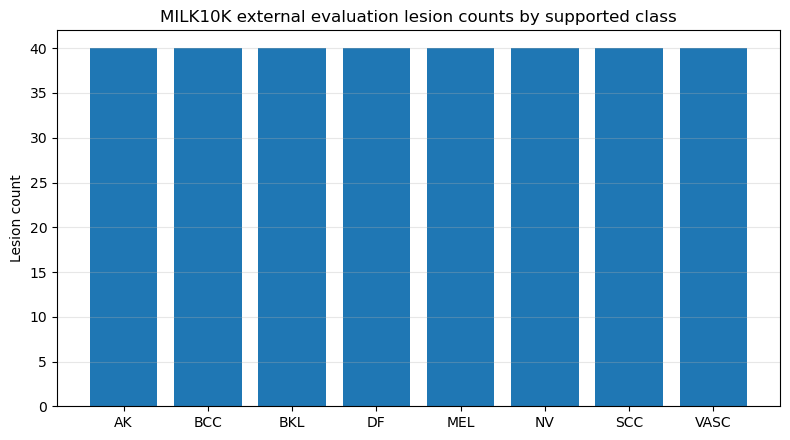

In [11]:
# ============================================================
# QUICK AUDIT OF THE ACTIVE EXTERNAL EVALUATION TABLE
# ============================================================

images_per_lesion = milk_eval_df.groupby("lesion_id").size().sort_values()
missing_image_paths = (~milk_eval_df["image_exists"]).sum()

print("Images per lesion distribution:")
print(images_per_lesion.value_counts().sort_index())
print()

print("Missing image paths in active evaluation set:", int(missing_image_paths))
print()

print("Image types in active evaluation set:")
print(milk_eval_df["image_type"].value_counts().sort_index())
print()

display(
    milk_eval_df[
        ["lesion_id", "isic_id", "image_type", "milk_label_raw", "label", "image_path"]
    ].head(10)
)

# Simple lesion-count bar chart
lesion_count_plot = (
    milk_eval_lesions_df["label"]
    .value_counts()
    .reindex(CANONICAL_LABELS)
)

plt.figure(figsize=(8, 4.5))
plt.bar(lesion_count_plot.index, lesion_count_plot.values)
plt.title("MILK10K external evaluation lesion counts by supported class")
plt.ylabel("Lesion count")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

if SAVE_FIGURES:
    plt.savefig(
        FIG_DIR / ("milk_supported_class_counts_smoke.png" if SMOKE_MODE else "milk_supported_class_counts_full.png"),
        dpi=200,
        bbox_inches="tight",
    )

plt.show()